# Exact-digit MNIST addition: class accuracy and channel correlations

Post-hoc analysis of one saved `scbm_residual` run on `MNIST-Add-Cov` /
`exact_digit_sum` (`datasets/MNIST_add_cov_dataset.py`).

The task is `y = d1 + d2` (19 classes). The bottleneck exposes six coarse bits
`[d1>=5, d1 prime, d1 even, d2>=5, d2 prime, d2 even]`; the **exact digit identity is
never supervised** and is kept only as oracle metadata (`exact_digits.pt`). At
threshold 5 the pairs `{0,4}`, `{5,7}`, `{6,8}` share a concept code, so the concept
block alone cannot always determine the sum -- recovering it is the residual's job.

Three things are computed here:

1. **Per-class accuracy** of the 19 sum classes, against the concept-only ceiling.
2. **Absolute correlation matrix** of the amortized `Sigma(x)` -- the *within-sample*
   coupling the SCBM models explicitly.
3. **Correlation matrix of `c_res_mu`** -- the *across-sample* correlation of the
   predicted concept/residual means.

(2) and (3) are different objects and routinely disagree: (2) is the average of
per-sample posterior correlations, (3) is the correlation of the posterior means over
the dataset. Read them together, not interchangeably.

Everything is read from the run's saved dumps, so no dataset rebuild and no data path
are needed.

In [1]:
%matplotlib inline
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "exact_digit_sum_exact_digit_R4_clean_prec_05_2026-09-12_21-05-23_seed_0_66979"
)

# The first line of log.txt is the full training config -- take C, R, the class count
# and the digit threshold from there rather than from the yaml, which may have moved on.
CONFIG = ast.literal_eval(RUN.joinpath("log.txt").read_text().splitlines()[0])
NUM_CONCEPTS = CONFIG["data"]["num_concepts"]
NUM_RESIDUALS = CONFIG["data"]["num_residuals"]
NUM_CLASSES = CONFIG["data"]["num_classes"]
THRESHOLD = CONFIG["data"]["digit_threshold"]
SPLITS = ("train", "val", "test")

CONCEPT_NAMES = [
    f"D1_HIGH(>={THRESHOLD})", "D1_PRIME", "D1_EVEN",
    f"D2_HIGH(>={THRESHOLD})", "D2_PRIME", "D2_EVEN",
][:NUM_CONCEPTS]
RESIDUAL_NAMES = [f"res_{j}" for j in range(NUM_RESIDUALS)]
CHANNEL_NAMES = CONCEPT_NAMES + RESIDUAL_NAMES

print(RUN.name)
print(f"C={NUM_CONCEPTS}  R={NUM_RESIDUALS}  classes={NUM_CLASSES}  threshold={THRESHOLD}")
print(f"head={CONFIG['model']['head_arch']}  concepts={CONFIG['model']['concept_learning']}  "
      f"cov={CONFIG['model']['cov_type']}  reg={CONFIG['model']['reg_precision']}"
      f"@{CONFIG['model']['reg_weight']}  corruption={CONFIG['data']['corruption']}")

exact_digit_sum_exact_digit_R4_clean_prec_05_2026-09-12_21-05-23_seed_0_66979
C=6  R=4  classes=19  threshold=5
head=linear  concepts=hard  cov=amortized  reg=l1@0.5  corruption=none


In [2]:
def load_split(split):
    """Saved dumps for one split.

    y_pred.pt holds MC-averaged *log-probabilities* for scbm_residual (despite the
    `target_pred_logits` name in utils/training.py), so it is exponentiated, not
    softmaxed -- softmaxing again would flatten the distribution and distort every
    probability-weighted quantity below. The assert is the check.
    """
    get = lambda name: torch.load(RUN / split / f"{name}.pt", map_location="cpu")

    y_logprob = get("y_pred")
    y_prob = y_logprob.exp().numpy()
    assert np.allclose(y_prob.sum(1), 1.0, atol=1e-4), "y_pred.pt is not log-probabilities"

    data = {
        "y_true": get("y_true").numpy().ravel(),
        "y_prob": y_prob,
        "y_hat": y_prob.argmax(1),
        "c_true": get("c_true").numpy().astype(int),
        "digits": get("exact_digits").numpy(),          # oracle: never supervised
        "c_res_mu": get("c_res_mu").numpy(),            # [N, C+R] posterior means
        "Sigma": get("covariance_matrices").numpy(),    # [N, C+R, C+R], already L L^T
        "Sigma_avg": get("avg_covariance_matrix").numpy(),
    }
    # y = d1 + d2 by construction; if this fails the dumps are misaligned.
    assert (data["digits"].sum(1) == data["y_true"]).all(), f"{split}: digits do not sum to y"
    return data


DATA = {split: load_split(split) for split in SPLITS}
for split, d in DATA.items():
    print(f"{split:<6} n={len(d['y_true']):<6} y_acc={(d['y_hat'] == d['y_true']).mean():.4f}")

train  n=12000  y_acc=0.6358
val    n=2400   y_acc=0.5350
test   n=10000  y_acc=0.5363


## 1. Per-class accuracy

`y` is a sum of two uniform digits, so its class prior is triangular (100 samples for
`y=0`, 1000 for `y=9` on a 10k test split). Raw per-class accuracy has to be read
against that support.

The reference line is the **concept-only ceiling**: the best accuracy any predictor
could reach seeing only the six true concept bits, i.e. predicting the majority sum
within each of the 49 occupied concept-code cells. A model at the ceiling is getting
nothing out of its residual channel.

In [3]:
def concept_only_ceiling(c_true, y_true):
    """Accuracy of the Bayes-optimal predictor on the six *true* concept bits.

    Each distinct 6-bit code is a cell; the best any concept-only predictor can do is
    the majority sum inside each cell. This is the ceiling the residual has to beat for
    the hidden digit identity to be doing any work.
    """
    code_id = (c_true * (2 ** np.arange(c_true.shape[1]))).sum(1)
    correct = sum(np.bincount(y_true[code_id == k]).max() for k in np.unique(code_id))
    return correct / len(y_true), len(np.unique(code_id))


print(f"{'split':<7}{'y_acc':>9}{'ceiling':>10}{'gain':>9}{'cells':>8}")
for split, d in DATA.items():
    ceiling, n_cells = concept_only_ceiling(d["c_true"], d["y_true"])
    acc = (d["y_hat"] == d["y_true"]).mean()
    print(f"{split:<7}{acc:>9.4f}{ceiling:>10.4f}{acc - ceiling:>+9.4f}{n_cells:>8}")

split      y_acc   ceiling     gain   cells
train     0.6358    0.5400  +0.0958      49
val       0.5350    0.5400  -0.0050      49
test      0.5363    0.5400  -0.0037      49


In [4]:
def per_class_table(d, num_classes=NUM_CLASSES):
    """Support, accuracy, recall-vs-precision and mean true-class probability per sum."""
    y_true, y_hat, y_prob = d["y_true"], d["y_hat"], d["y_prob"]
    rows = []
    for k in range(num_classes):
        is_k = y_true == k
        pred_k = y_hat == k
        rows.append({
            "class": k,
            "support": int(is_k.sum()),
            "accuracy": (y_hat[is_k] == k).mean() if is_k.any() else np.nan,
            "precision": (y_true[pred_k] == k).mean() if pred_k.any() else np.nan,
            "n_predicted": int(pred_k.sum()),
            "mean_p_true": y_prob[is_k, k].mean() if is_k.any() else np.nan,
        })
    return rows


SPLIT = "test"
print(f"{RUN.name}\nsplit = {SPLIT}\n")
print(f"{'y':>3}{'support':>9}{'acc':>8}{'prec':>8}{'n_pred':>8}{'mean p(y)':>11}")
for row in per_class_table(DATA[SPLIT]):
    print(f"{row['class']:>3}{row['support']:>9}{row['accuracy']:>8.3f}"
          f"{row['precision']:>8.3f}{row['n_predicted']:>8}{row['mean_p_true']:>11.3f}")

exact_digit_sum_exact_digit_R4_clean_prec_05_2026-09-12_21-05-23_seed_0_66979
split = test

  y  support     acc    prec  n_pred  mean p(y)
  0      100   0.000     nan       0      0.104
  1      200   0.965   0.489     395      0.234
  2      300   0.000     nan       0      0.155
  3      400   0.833   0.747     446      0.242
  4      500   0.752   0.601     626      0.369
  5      600   0.625   0.635     591      0.267
  6      700   0.706   0.644     767      0.317
  7      800   0.359   0.583     492      0.252
  8      900   0.930   0.649    1289      0.414
  9     1000   0.674   0.567    1188      0.339
 10      900   0.527   0.401    1183      0.220
 11      800   0.870   0.453    1537      0.292
 12      700   0.000   0.000       5      0.214
 13      600   0.315   0.622     304      0.221
 14      500   0.378   0.476     397      0.216
 15      400   0.393   0.227     691      0.164
 16      300   0.000     nan       0      0.152
 17      200   0.000     nan       0      0.

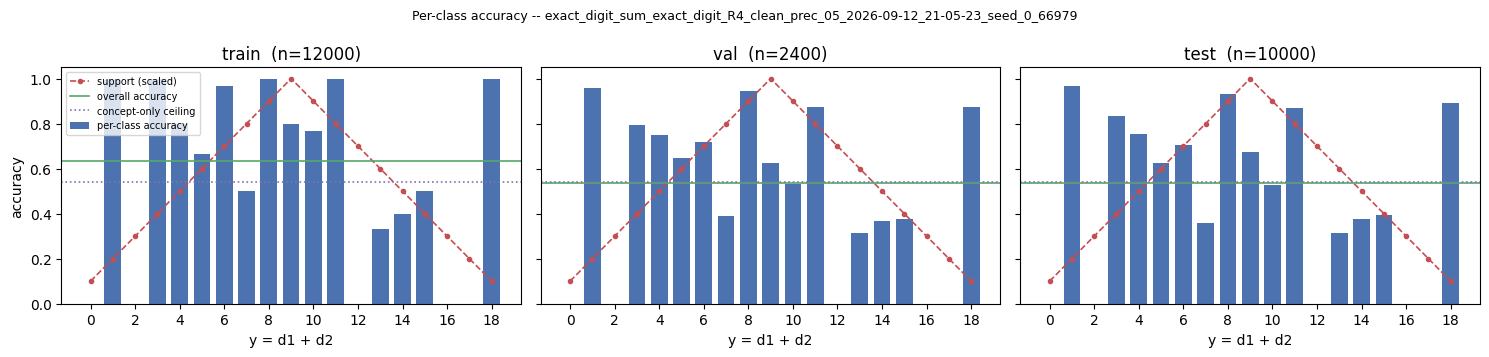

In [5]:
# Per-class accuracy against support, all splits. Classes the model never predicts
# (n_pred = 0 above) show as an accuracy of exactly zero -- a collapsed class, not a
# hard one, and the distinction matters when reading the confusion matrix next.
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5.0 * len(SPLITS), 3.6), sharey=True)

for ax, split in zip(np.atleast_1d(axes), SPLITS):
    d = DATA[split]
    rows = per_class_table(d)
    classes = [r["class"] for r in rows]
    acc = [r["accuracy"] for r in rows]
    support = np.array([r["support"] for r in rows], float)
    ceiling, _ = concept_only_ceiling(d["c_true"], d["y_true"])

    ax.bar(classes, acc, color="#4C72B0", width=0.75,
           label="per-class accuracy")
    ax.plot(classes, support / support.max(), color="#C44E52", lw=1.2, ls="--",
            marker="o", ms=3, label="support (scaled)")
    ax.axhline((d["y_hat"] == d["y_true"]).mean(), color="#55A868", lw=1.2,
               label="overall accuracy")
    ax.axhline(ceiling, color="#8172B2", lw=1.2, ls=":", label="concept-only ceiling")
    ax.set_title(f"{split}  (n={len(d['y_true'])})")
    ax.set_xlabel("y = d1 + d2")
    ax.set_xticks(range(0, NUM_CLASSES, 2))
    ax.set_ylim(0, 1.05)

np.atleast_1d(axes)[0].set_ylabel("accuracy")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"Per-class accuracy -- {RUN.name}", fontsize=9)
fig.tight_layout()
plt.show()

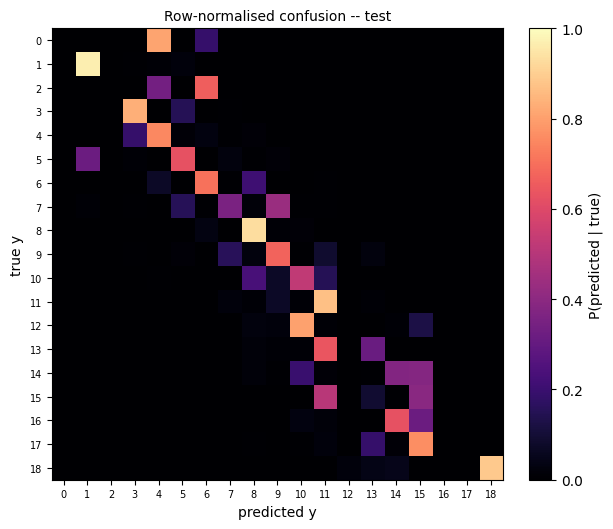

In [6]:
# Row-normalised confusion matrix: where does the mass of each true sum actually go?
# Rows are true y, columns predicted y, so a bright off-diagonal band at +-k means the
# model is systematically off by k -- the signature of resolving a digit to the wrong
# member of an ambiguous pair.
d = DATA[SPLIT]
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES))
np.add.at(confusion, (d["y_true"], d["y_hat"]), 1)
confusion_norm = confusion / np.maximum(confusion.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(confusion_norm, cmap="magma", vmin=0, vmax=1)
ax.set_xlabel("predicted y")
ax.set_ylabel("true y")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.tick_params(labelsize=7)
ax.set_title(f"Row-normalised confusion -- {SPLIT}", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, label="P(predicted | true)")
fig.tight_layout()
plt.show()

### Where the errors live: the ambiguous digit pairs

The per-class picture is driven by the designed concept collisions. Digits `{0,4}`,
`{5,7}` and `{6,8}` are pairwise indistinguishable from the concept bits, so the exact
sum is only identifiable when the residual resolves them. Splitting accuracy by the
oracle digits shows directly whether it does.

concept-code collisions: [[0, 4], [5, 7], [6, 8]]
ambiguous digits: [0, 4, 5, 6, 7, 8]


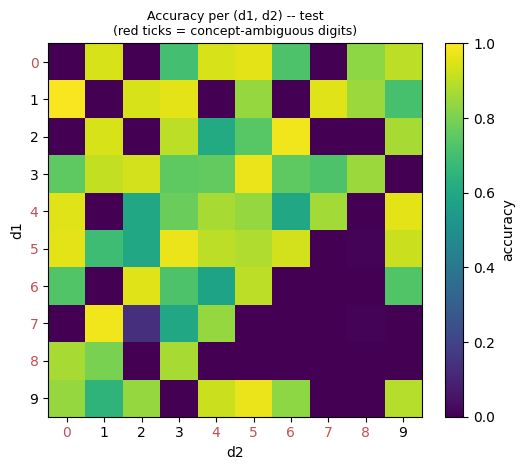


ambiguous digits in sample        n  accuracy
0                              1600     0.643
1                              4800     0.587
2                              3600     0.422


In [7]:
PRIMES = {2, 3, 5, 7}


def digit_code(digit):
    return (int(digit >= THRESHOLD), int(digit in PRIMES), int(digit % 2 == 0))


# Digits sharing a concept code are the ones the bottleneck cannot separate.
collisions = {}
for digit in range(10):
    collisions.setdefault(digit_code(digit), []).append(digit)
AMBIGUOUS = {d for group in collisions.values() if len(group) > 1 for d in group}
print("concept-code collisions:",
      [group for group in collisions.values() if len(group) > 1])
print("ambiguous digits:", sorted(AMBIGUOUS))

d = DATA[SPLIT]
correct = d["y_hat"] == d["y_true"]
d1, d2 = d["digits"][:, 0], d["digits"][:, 1]

# Accuracy per ordered digit pair.
pair_acc = np.full((10, 10), np.nan)
for a in range(10):
    for b in range(10):
        cell = (d1 == a) & (d2 == b)
        if cell.any():
            pair_acc[a, b] = correct[cell].mean()

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(pair_acc, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("d2"); ax.set_ylabel("d1")
for tick in ax.get_xticklabels():
    if int(tick.get_text()) in AMBIGUOUS: tick.set_color("#C44E52")
for tick in ax.get_yticklabels():
    if int(tick.get_text()) in AMBIGUOUS: tick.set_color("#C44E52")
ax.set_title(f"Accuracy per (d1, d2) -- {SPLIT}\n(red ticks = concept-ambiguous digits)",
             fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label="accuracy")
fig.tight_layout()
plt.show()

n_ambiguous = np.isin(d1, list(AMBIGUOUS)).astype(int) + np.isin(d2, list(AMBIGUOUS)).astype(int)
print(f"\n{'ambiguous digits in sample':<28}{'n':>7}{'accuracy':>10}")
for k in (0, 1, 2):
    cell = n_ambiguous == k
    print(f"{k:<28}{cell.sum():>7}{correct[cell].mean():>10.3f}")

In [8]:
# For each collision group, which member does the model resolve towards? A signed
# mean error that tracks the gap between the two members (e.g. -2 for {5,7}) means the
# model is reading the ambiguous digit as the other member of its pair, i.e. the
# residual is not carrying the identity.
print(f"{'digit':>6}{'n(d1)':>8}{'acc':>8}{'mean(yhat - y)':>16}")
for group in [g for g in collisions.values() if len(g) > 1]:
    for digit in group:
        cell = d1 == digit
        print(f"{digit:>6}{cell.sum():>8}{correct[cell].mean():>8.3f}"
              f"{np.mean(d['y_hat'][cell] - d['y_true'][cell]):>+16.2f}")
    print()

 digit   n(d1)     acc  mean(yhat - y)
     0    1000   0.599           +1.13
     4    1000   0.645           -0.52

     5    1000   0.686           -0.48
     7    1000   0.257           -1.55

     6    1000   0.461           +0.12
     8    1000   0.254           -1.16



## 2. Absolute correlation matrix of the amortized `Sigma(x)`

`covariance_matrices.pt` holds `Sigma = L L^T` per sample -- the validator already does
the reconstruction before saving, so the tensor **must not be squared again**.

Normalising each sample to `rho_ij = Sigma_ij / sqrt(Sigma_ii Sigma_jj)` and averaging
`|rho|` over samples gives the typical magnitude of coupling, which is what to plot:
signed entries average towards zero when the sign flips across samples, so a signed
mean can hide real structure.

**Read the diagonal of `Sigma` first.** On clean MNIST the concept posteriors sharpen
and the `Sigma` diagonal collapses, at which point every `rho` entry is a 0/0 ratio
with nothing to read off -- the caveat written into
[configs/data/mnist_add.yaml](configs/data/mnist_add.yaml). The diagnostic below is
printed before the heatmap for that reason.

In [9]:
def absolute_correlation(Sigma):
    """Mean |rho| over samples, plus the signed mean, from per-sample Sigma."""
    sd = np.sqrt(np.einsum("nii->ni", Sigma))
    rho = Sigma / (sd[:, :, None] * sd[:, None, :])
    return np.abs(rho).mean(0), rho.mean(0)


Sigma = DATA[SPLIT]["Sigma"]
abs_rho, signed_rho = absolute_correlation(Sigma)

diag = np.einsum("nii->ni", Sigma).mean(0)
print(f"mean Sigma diagonal ({SPLIT}):")
for name, value in zip(CHANNEL_NAMES, diag):
    print(f"  {name:<16}{value:>10.4f}")

off_diagonal = ~np.eye(len(CHANNEL_NAMES), dtype=bool)
cross_block = abs_rho[:NUM_CONCEPTS, NUM_CONCEPTS:]
print(f"\nmean |rho| off-diagonal      : {abs_rho[off_diagonal].mean():.5f}"
      f"   (max {abs_rho[off_diagonal].max():.5f})")
print(f"mean |rho| concept-residual  : {cross_block.mean():.5f}"
      f"   (max {cross_block.max():.5f})")
if cross_block.max() < 0.01:
    print("\n  WARNING: the concept-residual block is numerically zero. With clean images "
          "\n  Sigma(x) has collapsed and these entries carry no signal -- rerun with "
          "\n  corruption='gaussian', strength 0.5, channels 'all' before interpreting them.")

mean Sigma diagonal (test):
  D1_HIGH(>=5)       17.6781
  D1_PRIME            6.8661
  D1_EVEN             6.2953
  D2_HIGH(>=5)       17.6175
  D2_PRIME           10.7246
  D2_EVEN             7.1675
  res_0               9.3368
  res_1               1.7634
  res_2               3.7577
  res_3               2.6353

mean |rho| off-diagonal      : 0.00351   (max 0.01134)
mean |rho| concept-residual  : 0.00401   (max 0.00874)

  Sigma(x) has collapsed and these entries carry no signal -- rerun with 
  corruption='gaussian', strength 0.5, channels 'all' before interpreting them.


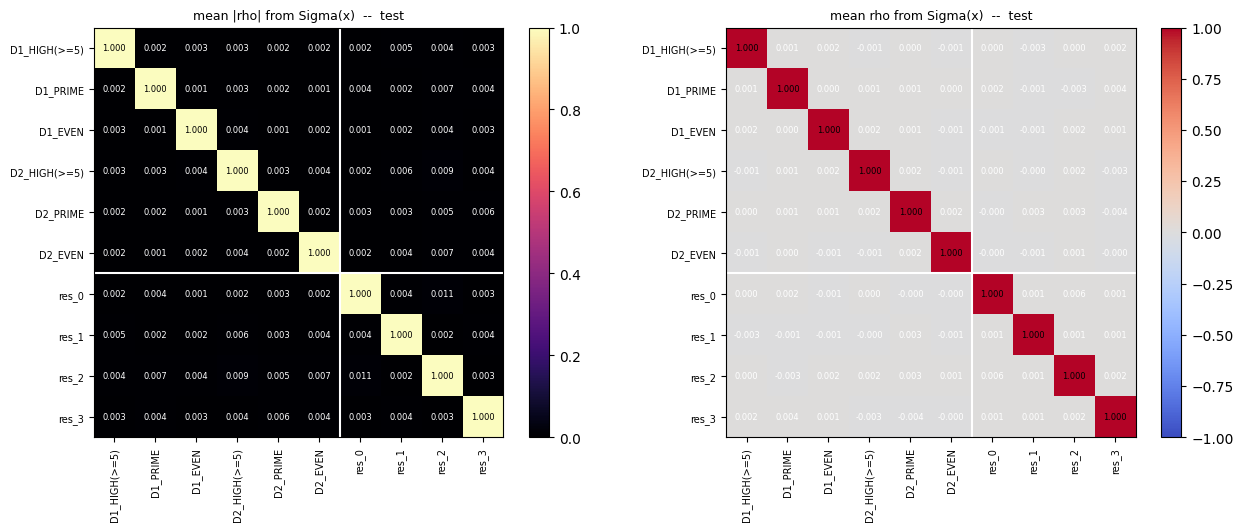

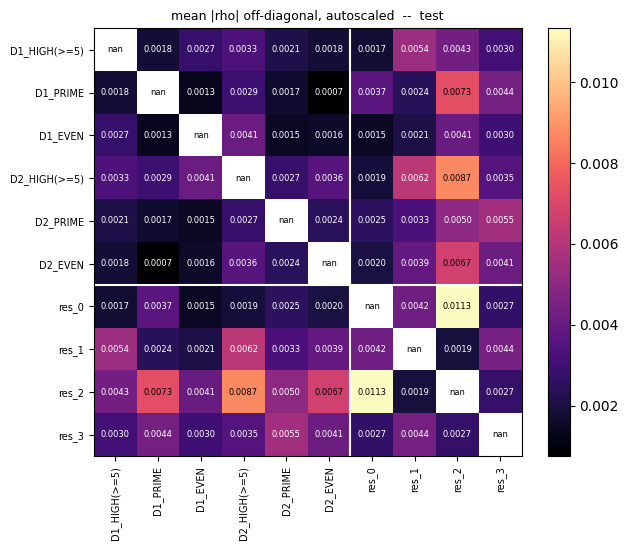

In [10]:
def plot_matrix(matrix, title, cmap="magma", vmin=None, vmax=None, fmt="{:.2f}",
                annotate=True, ax=None):
    """Labelled heatmap over the [concepts | residuals] channel, with the block split drawn."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 5.6))
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(CHANNEL_NAMES)), CHANNEL_NAMES, rotation=90, fontsize=7)
    ax.set_yticks(range(len(CHANNEL_NAMES)), CHANNEL_NAMES, fontsize=7)
    # The line separating the concept block from the residual block.
    for line in (ax.axvline, ax.axhline):
        line(NUM_CONCEPTS - 0.5, color="w", lw=1.5)
    if annotate:
        span = (np.nanmax(matrix) - np.nanmin(matrix)) or 1.0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                shade = (matrix[i, j] - np.nanmin(matrix)) / span
                ax.text(j, i, fmt.format(matrix[i, j]), ha="center", va="center",
                        fontsize=6, color="w" if shade < 0.55 else "k")
    ax.set_title(title, fontsize=9)
    ax.figure.colorbar(im, ax=ax, fraction=0.046)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
plot_matrix(abs_rho, f"mean |rho| from Sigma(x)  --  {SPLIT}", vmin=0, vmax=1,
            fmt="{:.3f}", ax=axes[0])
plot_matrix(signed_rho, f"mean rho from Sigma(x)  --  {SPLIT}", cmap="coolwarm",
            vmin=-1, vmax=1, fmt="{:.3f}", ax=axes[1])
fig.tight_layout()
plt.show()

# The same on the off-diagonal scale, where any surviving structure is visible.
off = abs_rho.copy()
np.fill_diagonal(off, np.nan)
plot_matrix(off, f"mean |rho| off-diagonal, autoscaled  --  {SPLIT}", fmt="{:.4f}")
plt.tight_layout()
plt.show()

## 3. Correlation matrix of `c_res_mu`

`c_res_mu.pt` is the predicted Gaussian **mean** `[mu_c(x) | mu_r(x)]`, one row per
sample. Its Pearson correlation across the dataset is a different quantity from
section 2: section 2 asks how concepts and residuals co-vary *within* a sample's
posterior, this asks how their predicted means co-vary *across* inputs.

A residual column correlating strongly with a concept column here is leakage -- the
residual mean tracking information already present in the bottleneck. That is what the
OLS-cleaning step of the pipeline removes before the residual is scored against hidden
concepts.

c_res_mu.shape = (10000, 10)   split = test

channel                 mean       std
D1_HIGH(>=5)          -2.614    45.249
D1_PRIME              -4.252    39.454
D1_EVEN                7.284    30.784
D2_HIGH(>=5)          -2.495    44.620
D2_PRIME              -4.053    38.369
D2_EVEN                6.956    30.442
res_0                -36.860    41.385
res_1                 13.113    49.446
res_2                 30.168    45.545
res_3                -27.494    47.056


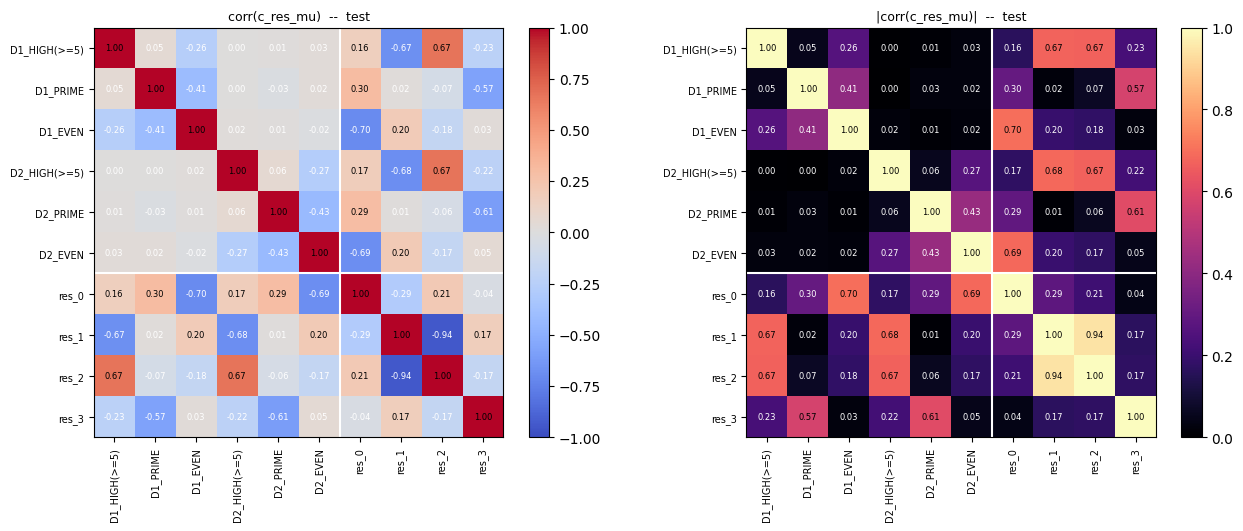

In [11]:
mu = DATA[SPLIT]["c_res_mu"]
corr_mu = np.corrcoef(mu.T)

print(f"c_res_mu.shape = {mu.shape}   split = {SPLIT}\n")
print(f"{'channel':<18}{'mean':>10}{'std':>10}")
for name, column in zip(CHANNEL_NAMES, mu.T):
    print(f"{name:<18}{column.mean():>10.3f}{column.std():>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
plot_matrix(corr_mu, f"corr(c_res_mu)  --  {SPLIT}", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[0])
plot_matrix(np.abs(corr_mu), f"|corr(c_res_mu)|  --  {SPLIT}", vmin=0, vmax=1,
            ax=axes[1])
fig.tight_layout()
plt.show()

In [12]:
# Leakage summary: how much of each residual mean is linearly explained by the
# concept means? R^2 of res_j regressed on [1, mu_c] -- the same quantity the cleaning
# step removes. A high R^2 means the raw residual column is mostly restating the
# bottleneck, and any AUROC measured on it before cleaning is not evidence of a
# recovered hidden concept.
c_mu, res_mu = mu[:, :NUM_CONCEPTS], mu[:, NUM_CONCEPTS:]
design = np.concatenate([np.ones((len(mu), 1)), c_mu], axis=1)
beta, *_ = np.linalg.lstsq(design, res_mu, rcond=None)
res_clean = res_mu - design @ beta

print(f"{'residual':<10}{'R^2 on c_mu':>14}{'max |corr| w/ concept':>24}")
for j, name in enumerate(RESIDUAL_NAMES):
    r2 = 1 - res_clean[:, j].var() / res_mu[:, j].var()
    concept_corr = np.abs(corr_mu[NUM_CONCEPTS + j, :NUM_CONCEPTS])
    strongest = CONCEPT_NAMES[concept_corr.argmax()]
    print(f"{name:<10}{r2:>14.3f}{concept_corr.max():>18.3f}  ({strongest})")

print(f"\nresidual-residual |corr| (off-diagonal): "
      f"mean {np.abs(corr_mu[NUM_CONCEPTS:, NUM_CONCEPTS:])[~np.eye(NUM_RESIDUALS, dtype=bool)].mean():.3f}")

residual     R^2 on c_mu   max |corr| w/ concept
res_0              0.977             0.695  (D1_EVEN)
res_1              0.932             0.684  (D2_HIGH(>=5))
res_2              0.925             0.672  (D2_HIGH(>=5))
res_3              0.951             0.609  (D2_PRIME)

residual-residual |corr| (off-diagonal): mean 0.303


## Splits side by side

All three matrices are recomputed per split as a stability check -- structure that only
shows up on one split is a property of that split, not of the model.

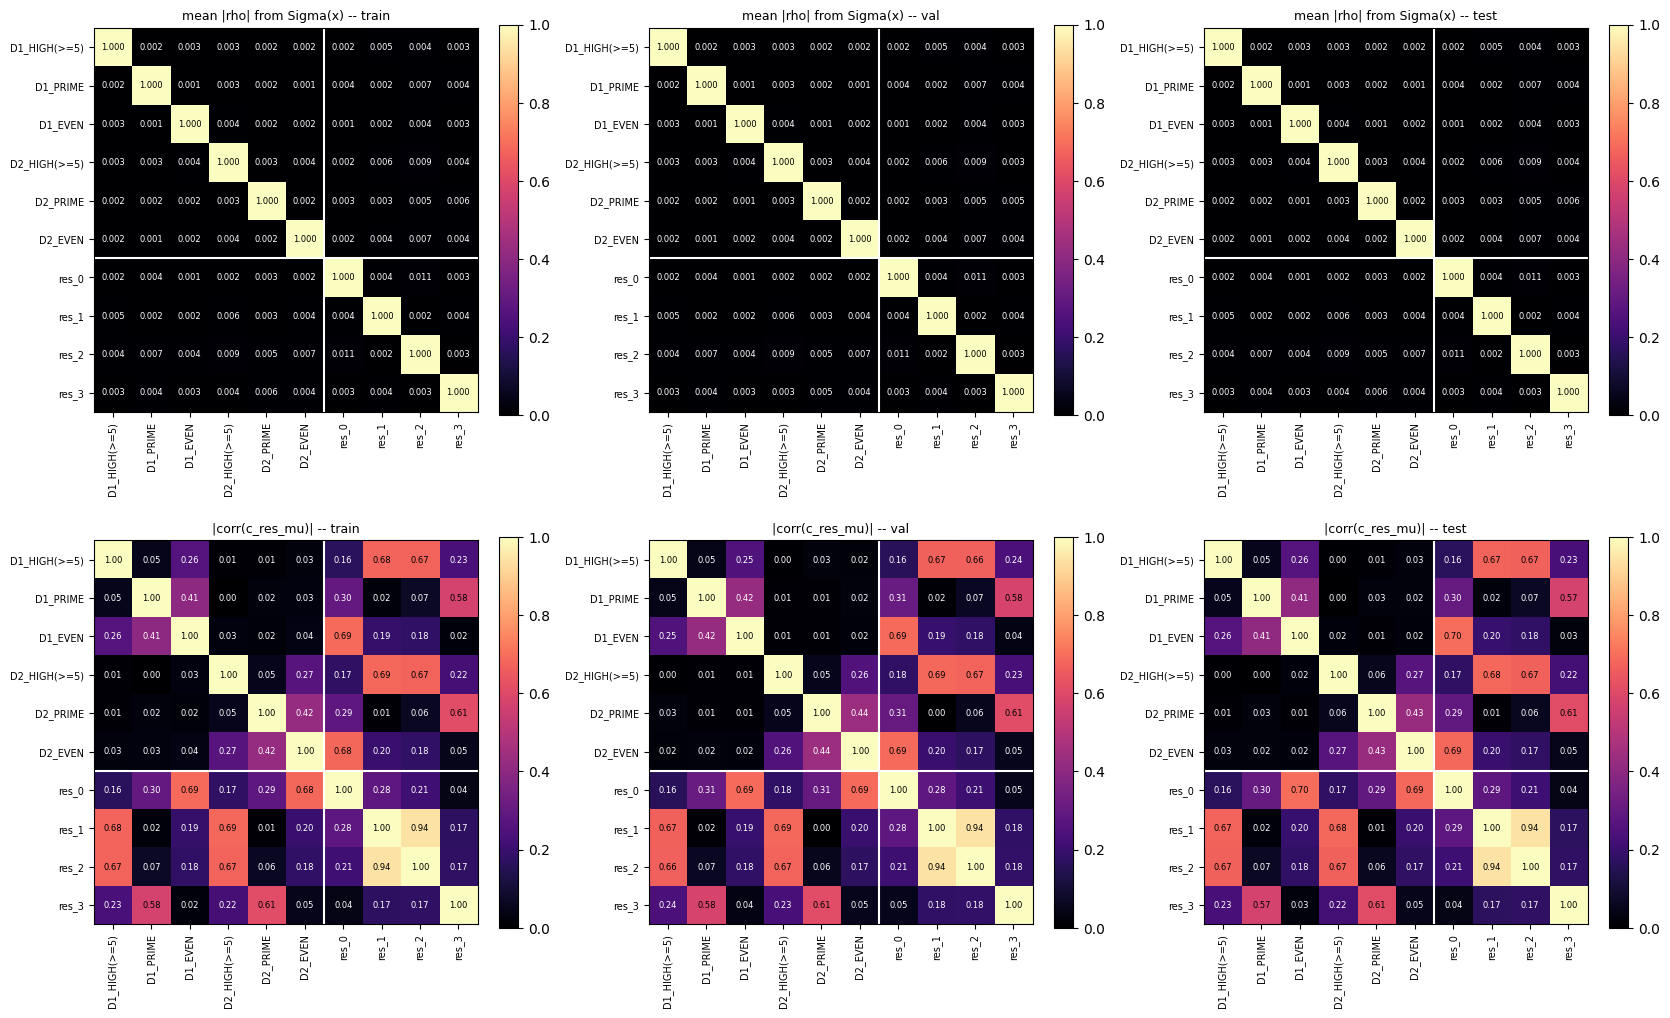

In [13]:
fig, axes = plt.subplots(2, len(SPLITS), figsize=(5.6 * len(SPLITS), 10.4))
for column, split in enumerate(SPLITS):
    abs_rho_split, _ = absolute_correlation(DATA[split]["Sigma"])
    plot_matrix(abs_rho_split, f"mean |rho| from Sigma(x) -- {split}", vmin=0, vmax=1,
                fmt="{:.3f}", ax=axes[0, column])
    plot_matrix(np.abs(np.corrcoef(DATA[split]["c_res_mu"].T)),
                f"|corr(c_res_mu)| -- {split}", vmin=0, vmax=1, ax=axes[1, column])
fig.tight_layout()
plt.show()